<a href="https://colab.research.google.com/github/kishansharathgowda23-oss/Job-recommendation-ml/blob/main/AIINACTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.9 MB/s eta 0:00:00
Upload Dataset ZIP


Saving Job_Descriptions.zip to Job_Descriptions.zip


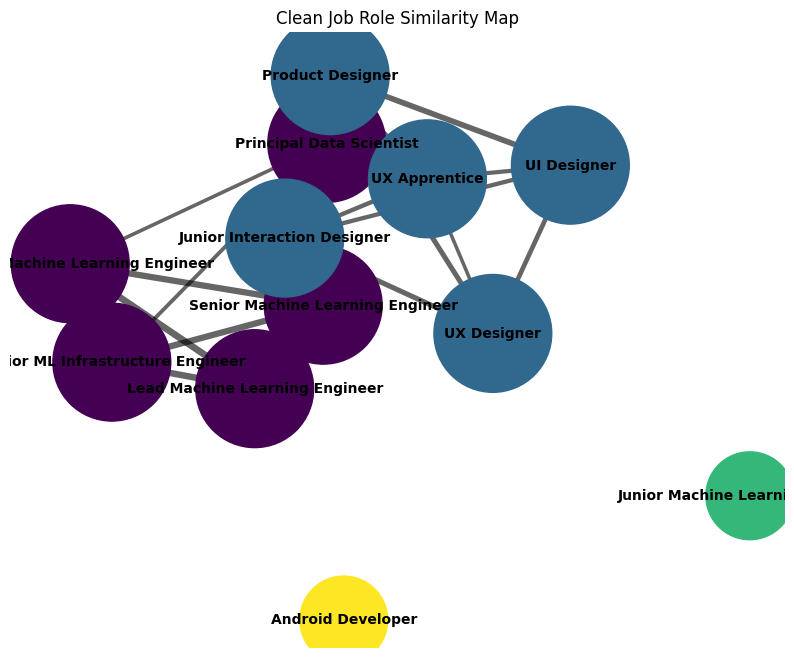

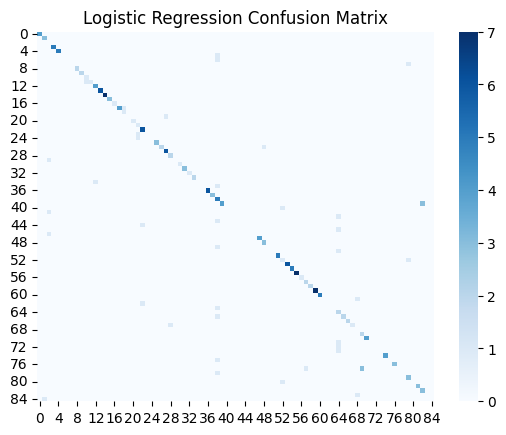

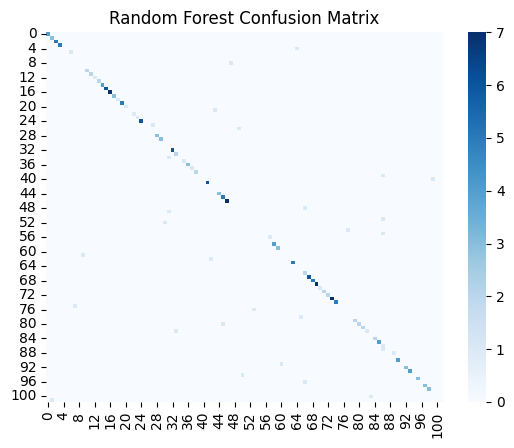

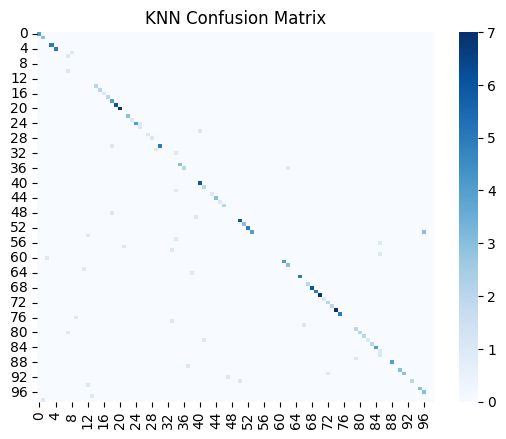

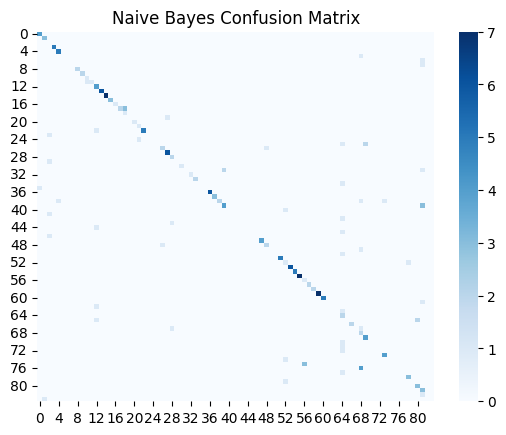

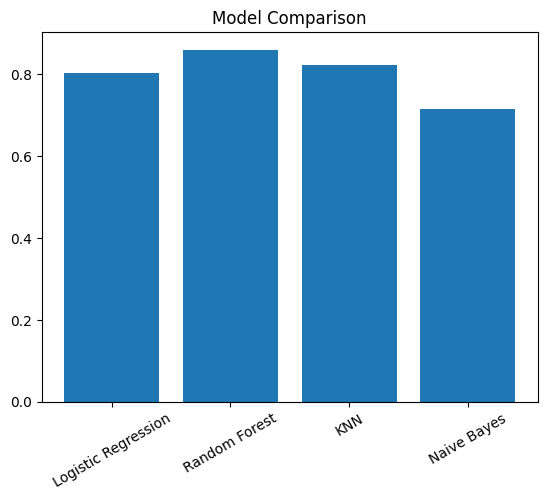

Upload Resume PDF


Saving kome-default.pdf to kome-default.pdf

Top Job Recommendations:

----------------------------------
Job Role       : .NET Developer
Match Score    : 77.52 %
Matching Skills: ['c#', 'sql server', 'asp.net', 'css', 'html']
Missing Skills : ['.net framework']
Priority Skills: ['.net framework']
----------------------------------
Job Role       : .NET Developer
Match Score    : 62.73 %
Matching Skills: ['asp.net mvc', 'sql server', 'c#']
Missing Skills : ['entity framework basics', '.net core basics', 'git']
Priority Skills: ['entity framework basics', '.net core basics', 'git']
----------------------------------
Job Role       : .NET Developer
Match Score    : 63.5 %
Matching Skills: ['c#', 'sql server', 'asp.net mvc', 'css', 'html']
Missing Skills : ['javascript basics', 'git', 'vb.net basics', '.net core']
Priority Skills: ['javascript basics', 'git', 'vb.net basics']
----------------------------------

Predicted Role: .NET Developer
Predicted Experience Level: Mid-Level

Learning

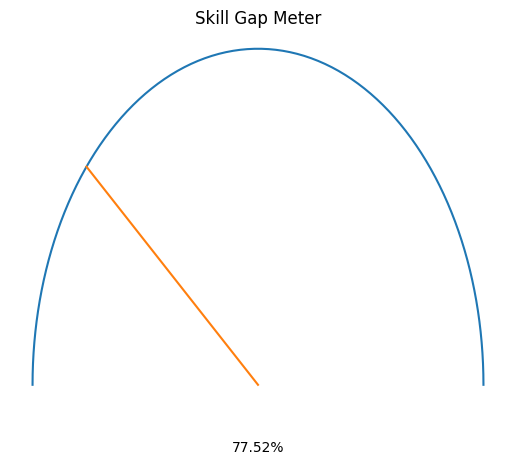

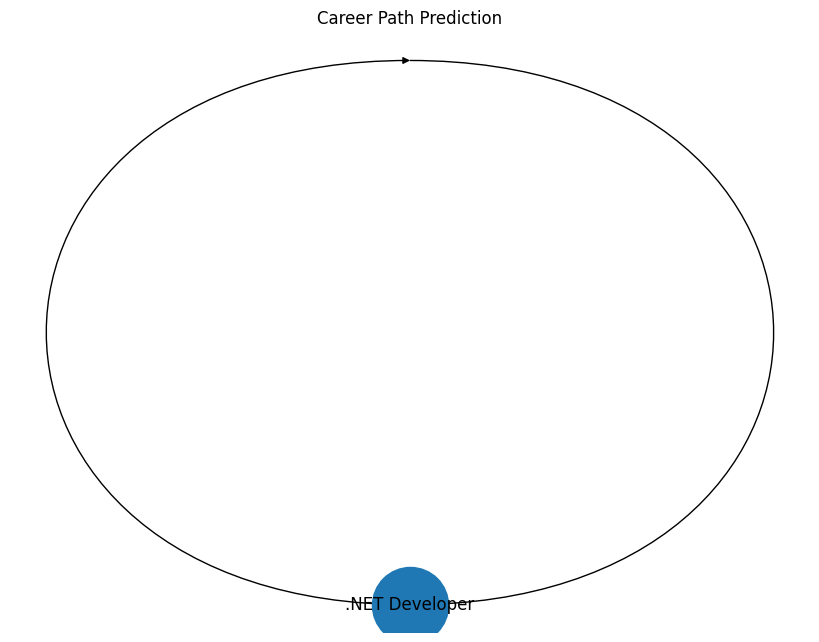


Top Demand Skills:
1. python → 220
2. communication → 167
3. git → 156
4. leadership → 150
5. problem-solving → 147
6. java → 140
7. sql → 134
8. python basics → 129
9. docker → 118
10. aws → 102


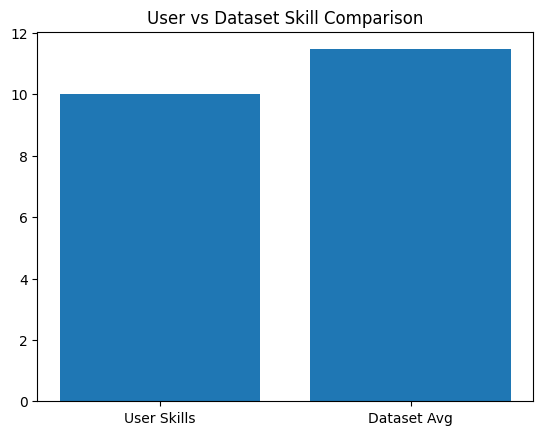

In [ ]:
# =========================================
# 1. INSTALL
# =========================================
!pip install scikit-learn pandas matplotlib PyPDF2 seaborn networkx

# =========================================
# 2. IMPORTS
# =========================================
import pandas as pd
import json, zipfile, os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import PyPDF2

from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from collections import Counter

# =========================================
# 3. UPLOAD DATASET (ZIP)
# =========================================
print("Upload Dataset ZIP")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data")

# =========================================
# 4. LOAD DATA
# =========================================
df = None
for file in os.listdir("data"):
    if file.endswith(".json"):
        with open(os.path.join("data", file)) as f:
            df = pd.DataFrame(json.load(f))
    elif file.endswith(".csv"):
        df = pd.read_csv(os.path.join("data", file))

# =========================================
# 5. PREPROCESSING
# =========================================
def clean_skills(x):
    if isinstance(x, str):
        try:
            return [i.strip().lower() for i in eval(x)]
        except:
            return x.lower().split(',')
    return [i.lower() for i in x]

df['Skills'] = df['Skills'].apply(clean_skills)
df['Skills_Text'] = df['Skills'].apply(lambda x: ' '.join(x))

le = LabelEncoder()
df['Job_Label'] = le.fit_transform(df['Title'])

# =========================================
# 6. ✅ CLEAN JOB ROLE SIMILARITY MAP
# =========================================
role_skills = df.groupby('Title')['Skills_Text'].apply(lambda x: ' '.join(x)).reset_index()

vectorizer_graph = TfidfVectorizer()
role_X = vectorizer_graph.fit_transform(role_skills['Skills_Text'])

role_similarity = cosine_similarity(role_X)

G = nx.Graph()
threshold = 0.4

for i in range(len(role_skills)):
    for j in range(i+1, len(role_skills)):
        if role_similarity[i][j] > threshold:
            G.add_edge(
                role_skills.iloc[i]['Title'],
                role_skills.iloc[j]['Title'],
                weight=role_similarity[i][j]
            )

# Keep only top roles
degree_dict = dict(G.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:12]
G = G.subgraph(top_nodes)

# Community coloring
from networkx.algorithms import community
communities = community.greedy_modularity_communities(G)

color_map = {}
for i, com in enumerate(communities):
    for node in com:
        color_map[node] = i

node_colors = [color_map[node] for node in G.nodes()]

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, k=1.2, seed=42)

node_sizes = [4000 + 800 * G.degree(n) for n in G.nodes()]
edges = G.edges(data=True)
weights = [d['weight'] * 5 for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors)
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Clean Job Role Similarity Map")
plt.axis('off')
plt.show()

# =========================================
# 7. TRAIN MODELS
# =========================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Skills_Text'])
y = df['Job_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": MultinomialNB()
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    accuracies[name] = acc

    cm = confusion_matrix(y_test, preds)

    plt.figure()
    sns.heatmap(cm, cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# =========================================
# 8. MODEL COMPARISON
# =========================================
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

# =========================================
# 9. SKILL FUNCTIONS
# =========================================
all_skills = [s for sub in df['Skills'] for s in sub]

def extract_skills(text):
    return list(set([skill for skill in all_skills if skill in text]))

def skill_gap(user, job):
    common = set(user) & set(job)
    missing = set(job) - set(user)
    score = len(common)/len(job)*100 if job else 0
    return round(score,2), list(common), list(missing)

# =========================================
# 10. UPLOAD RESUME
# =========================================
print("Upload Resume PDF")
uploaded = files.upload()
pdf_file = list(uploaded.keys())[0]

reader = PyPDF2.PdfReader(pdf_file)
user_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        user_text += text.lower()

user_skills = extract_skills(user_text)

# =========================================
# 11. JOB MATCHING
# =========================================
user_vec = vectorizer.transform([user_text])
similarity = cosine_similarity(user_vec, X)

df['Match'] = similarity[0]
top = df.sort_values(by='Match', ascending=False).head(3)

# =========================================
# 12. SCORING + OUTPUT
# =========================================
final_scores = []

print("\nTop Job Recommendations:\n")
print("----------------------------------")

for _, row in top.iterrows():
    score, common, missing = skill_gap(user_skills, row['Skills'])
    final_score = (row['Match']*100)*0.6 + score*0.4
    final_scores.append(final_score)

    priority = missing[:3]

    print(f"Job Role       : {row['Title']}")
    print(f"Match Score    : {round(final_score,2)} %")
    print(f"Matching Skills: {common}")
    print(f"Missing Skills : {missing}")
    print(f"Priority Skills: {priority}")
    print("----------------------------------")

# =========================================
# 13. PREDICTION
# =========================================
best_index = np.argmax(final_scores)
predicted_role = top.iloc[best_index]['Title']

experience = "Beginner"
if max(final_scores) > 70:
    experience = "Mid-Level"
if max(final_scores) > 85:
    experience = "Advanced"

print(f"\nPredicted Role: {predicted_role}")
print(f"Predicted Experience Level: {experience}")

# =========================================
# 14. LEARNING PATH
# =========================================
all_missing = []

for _, row in top.iterrows():
    _, _, missing = skill_gap(user_skills, row['Skills'])
    all_missing.extend(missing)

learning_path = list(dict.fromkeys(all_missing))[:5]

print("\nLearning Path:")
for i, skill in enumerate(learning_path):
    print(f"Step {i+1}: Learn {skill}")

# =========================================
# 15. SKILL GAP METER
# =========================================
best_score = max(final_scores)

fig, ax = plt.subplots()
theta = np.linspace(0, np.pi, 100)
r = 1

ax.plot(r*np.cos(theta), r*np.sin(theta))

angle = (best_score/100) * np.pi
ax.plot([0, r*np.cos(angle)], [0, r*np.sin(angle)])

ax.text(0, -0.2, f"{round(best_score,2)}%", ha='center')
ax.set_title("Skill Gap Meter")
ax.axis('off')
plt.show()

# =========================================
# 16. CAREER PATH GRAPH
# =========================================
G2 = nx.DiGraph()
roles = top['Title'].tolist()

for i in range(len(roles)-1):
    G2.add_edge(roles[i], roles[i+1])

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G2)
nx.draw(G2, pos, with_labels=True, node_size=3000)
plt.title("Career Path Prediction")
plt.show()

# =========================================
# 17. DEMAND SKILLS ANALYSIS
# =========================================
skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(10)

print("\nTop Demand Skills:")
for i, (skill, count) in enumerate(top_skills):
    print(f"{i+1}. {skill} → {count}")

# =========================================
# 18. USER vs DATASET SKILL COMPARISON
# =========================================
dataset_avg = len(all_skills) / len(df)
user_skill_count = len(user_skills)

plt.figure()
plt.bar(["User Skills", "Dataset Avg"], [user_skill_count, dataset_avg])
plt.title("User vs Dataset Skill Comparison")
plt.show()